In [1]:
import os
from dotenv import load_dotenv

from google.cloud import bigquery

import pandas as pd

import openai
from pinecone import Pinecone, ServerlessSpec          # v3 client
from langchain_pinecone import PineconeVectorStore     # new LC wrapper
# from langchain.embeddings.openai import OpenAIEmbeddings # old langchain version?
from langchain_openai import OpenAIEmbeddings
#from langchain.docstore.document import Document # old langchain version?
from langchain_core.documents.base import Document

from conversation_manager import ConversationManager

load_dotenv()

# set API keys
OPENAI_KEY=os.getenv("OPENAI_API_KEY")
OPENAI_BASE='https://www.khanacademy.org/api/internal/_ai-router/openai/v1/'
PINECONE_KEY = os.getenv('PINECONE_API_KEY')

# Debug: Check if environment variables are loaded
print(f"OPENAI_KEY loaded: {'Yes' if OPENAI_KEY else 'No'}")
print(f"OPENAI_BASE loaded: {'Yes' if OPENAI_BASE else 'No'}")
print(f"PINECONE_KEY loaded: {'Yes' if PINECONE_KEY else 'No'}")

# Check if any required keys are missing
if not OPENAI_KEY:
    print("ERROR: OPENAI_API_KEY is not set!")
if not PINECONE_KEY:
    print("ERROR: PINECONE_API_KEY is not set!")


openai_client = openai.OpenAI(
    base_url = OPENAI_BASE,
    api_key = OPENAI_KEY)

client=bigquery.Client(project='khanacademy.org:deductive-jet-827')


OPENAI_KEY loaded: Yes
OPENAI_BASE loaded: Yes
PINECONE_KEY loaded: Yes


In [2]:
# get the history data 
query = """
with lib as (
SELECT DISTINCT
      content_path.content_slug,
      content_path.content_id
    FROM `khan-core.content.published_content_paths_daily`
    WHERE dt = '2025-10-06'
      AND locale = 'en'
      and content_path.domain_slug='math'
      
      )
, threads as ( 
select distinct a.userKaid as kaid,
 a.aiGuideThreadId, 
 a.contentId,
 a.contentKind, 
 a.delta_dt,
 b.content_slug
 FROM `khan-data-lake.analytics_events.AiGuideInteractionStored_materialized` a
left join lib b
 
on a.contentId=b.content_id 
where a.eventInfo.eventTime>'2025-08-05'
and a.aiGuideExperienceReportingLabelId='content-tutoring'
and a.userKaid='kaid_248328473686127753888179'
)
, text as (
select kaid, 
threadId, 
string_agg(concat(conversationEntryType, ": ", text), " ") as thread_text
from (
    select kaid,
    threadId, 
    conversationEntryType, text
    from `khan-iris.aiguide.conversation_entries`
    where dt > '2025-08-05'
    and threadID in (select aiGuideThreadId from threads)
    --AND threadID in (select aiGuideThreadId from user_lengths)
    order by threadID, conversationEntryTime
) group by 1, 2  
)
-- need tp adjust fpm to just get current state at today
, fpm AS (
  SELECT distinct
    a.kaid,
    a.skill_id,
  -- a.skill_fpm_before_level,
  --  a.skill_fpm_after_level
    LAST_VALUE(a.skill_fpm_after_level) OVER (PARTITION BY a.kaid, skill_id ORDER BY a.fpm_event_ts ASC ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) AS last_fpm_level
    FROM `khan-core.mastery.fpm_events` as a
    where fpm_event_dt between '2025-08-05' and CURRENT_DATE()
    and kaid in (select kaid from threads)
  and task_type= 'practice_tutorial'
)
select
  kaid, 
  aiGuideThreadId as turn_id,
  content_slug as skill_tag,
  delta_dt as dt,
  last_fpm_level as fpm_state,
  thread_text as text
  from (
select threads.*, 
  text.thread_text,
  --fpm.skill_fpm_before_level,
  fpm.last_fpm_level  
  from threads 
  left join text on 
  threads.kaid=text.kaid and 
  threads.AiGuideThreadId = text.threadId
  left join fpm on 
  threads.kaid=fpm.kaid and 
  threads.contentID = fpm.skill_id
  ) 
 """

# query with prereqs and fpm on those
query2="""
with lib as (
SELECT DISTINCT
      content_path.content_slug,
      content_path.content_id
    FROM `khan-core.content.published_content_paths_daily`
    WHERE dt = '2025-10-06'
      AND locale = 'en'
      and content_path.domain_slug='math'
      
      )
, threads as ( 
select distinct a.userKaid as kaid,
 a.aiGuideThreadId, 
 a.contentId,
 a.contentKind, 
 a.delta_dt,
 b.content_slug
 FROM `khan-data-lake.analytics_events.AiGuideInteractionStored_materialized` a
left join lib b
 
on a.contentId=b.content_id 
where a.eventInfo.eventTime>'2025-08-05'
and a.aiGuideExperienceReportingLabelId='content-tutoring'
and a.userKaid='kaid_248328473686127753888179'
)
, text as (
select kaid, 
threadId, 
string_agg(concat(conversationEntryType, ": ", text), " ") as thread_text
from (
    select kaid,
    threadId, 
    conversationEntryType, text
    from `khan-iris.aiguide.conversation_entries`
    where dt > '2025-08-05'
    and threadID in (select aiGuideThreadId from threads)
    --AND threadID in (select aiGuideThreadId from user_lengths)
    order by threadID, conversationEntryTime
) group by 1, 2  
)
-- need tp adjust fpm to just get current state at today
, fpm AS (
  SELECT distinct
    a.kaid,
    a.skill_id,
  -- a.skill_fpm_before_level,
  --  a.skill_fpm_after_level
    LAST_VALUE(a.skill_fpm_after_level) OVER (PARTITION BY a.kaid, skill_id ORDER BY a.fpm_event_ts ASC ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) AS last_fpm_level
    FROM `khan-core.mastery.fpm_events` as a
    where fpm_event_dt between '2025-08-05' and CURRENT_DATE()
    --and kaid='kaid_248328473686127753888179'
    and kaid in (select kaid from threads)
  and task_type= 'practice_tutorial'
) 
, prereqs as (select a.*,
 lib.content_id as prereq_content_id from (
 SELECT
  learnableContentRevision.slug,
  learnableContentRevision.contentId,
  json_value(prereq_element) AS prerequisite,
  MAX(eventInfo.eventTime) AS latest_version,
FROM
  `khan-data-lake.analytics_events.ExerciseRevisionPublish_materialized`  ,
  UNNEST(JSON_EXTRACT_ARRAY(prerequisitesJson)) AS prereq_element
WHERE
  learnableContentRevision.kaLocale = 'en'
GROUP BY
  learnableContentRevision.slug,
  learnableContentRevision.contentId,
  prereq_element
) a
  left join lib on 
  lib.content_slug = a.prerequisite
  ) 
, prereq_fpm as (
  SELECT distinct
    a.kaid,
    a.skill_id as prereq_content_id,
  -- a.skill_fpm_before_level,
  --  a.skill_fpm_after_level
    LAST_VALUE(a.skill_fpm_after_level) OVER (PARTITION BY a.kaid, skill_id ORDER BY a.fpm_event_ts ASC ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING) AS prereq_fpm_level
    FROM `khan-core.mastery.fpm_events` as a
    where fpm_event_dt between '2024-08-05' and CURRENT_DATE()
    --and kaid='kaid_248328473686127753888179'
    and kaid in (select kaid from threads)
    and skill_id in (select prereq_content_id from prereqs)
    and task_type= 'practice_tutorial'
)
, hist as (
select
  kaid, 
  aiGuideThreadId as turn_id,
  contentId,
  content_slug as skill_tag,
  delta_dt as dt,
  last_fpm_level as fpm_state,
  thread_text as text
  from (
select threads.*, 
  text.thread_text,
  --fpm.skill_fpm_before_level,
  fpm.last_fpm_level
  from threads 
  left join text on 
  threads.kaid=text.kaid and 
  threads.AiGuideThreadId = text.threadId
  left join fpm on 
  threads.kaid=fpm.kaid and 
  threads.contentID = fpm.skill_id
  )
)
select 
  kaid, 
  turn_id,
  skill_tag,
  dt, 
  fpm_state,
  prerequisite,
  case when prereq_fpm_level is null then 'unknown' else prereq_fpm_level end as prereq_fpm_level,
  text
  from (
select hist.*,
b.prereq_content_id,
b.prerequisite ,
c.prereq_fpm_level
from hist 
left join prereqs b 
on hist.contentId = b.contentId
left join prereq_fpm c 
on b.prereq_content_id = c.prereq_content_id
)
"""

In [3]:
# create vector DB and upsert docs
INDEX_NAME       = "student"
DIMENSION        = 1536                    
METRIC           = "cosine"                

# init pinecone 
pc = Pinecone(api_key=PINECONE_KEY)
# create index  
if not pc.has_index(INDEX_NAME):
    pc.create_index(
        name=INDEX_NAME,
        dimension=DIMENSION,
        metric=METRIC,
        spec=ServerlessSpec(cloud="gcp", region="us-central1")
    )

index = pc.Index(INDEX_NAME)

# # Initialize the embedder
embedder = OpenAIEmbeddings(
    model="text-embedding-3-small",
    base_url=OPENAI_BASE, # had to add base url
    openai_api_key=OPENAI_KEY
)
# create the vector store 
vector_store = PineconeVectorStore(index, embedder)

# build and upload docs 
def build_docs(rows):
    docs=[]
    for kaid, turn_id, skill_tag, dt, fpm_state, prerequisite, prereq_fpm_level, text in rows:
        metadata={'kaid': kaid, 
                  'turn_id': turn_id, 
                  'skill_tag': skill_tag, 
                  'date': str(dt), 
                  'fpm_state': fpm_state,
                  'prerequisite': prerequisite,
                  'prereq_fpm_level': prereq_fpm_level}
        docs.append(Document(page_content=text, metadata=metadata))
    return docs

rows=client.query(query2)
docs = build_docs(rows)

vector_store.add_documents(docs)

        

['2acc8507-c4d1-4224-98d3-5dc8fb37558c',
 '63772f7c-4cef-45d0-b266-961edf4b10e8',
 'c1b39ace-bb13-4c19-9da0-fc782ce6d4e3',
 'a38e9316-21b8-4c88-8e9b-467bb9e20770',
 'e30e91ba-d835-43e1-8433-7cbdad41a6a6',
 'dc0ab66e-43e9-4336-9060-e8d4660668c7',
 '75493394-3b5f-4319-93f0-8d39020664b5',
 '740915ce-6012-4800-bf63-3add508602c3',
 'e60710ff-1873-484a-8273-b3e1e0c4a285',
 'ac1914ec-f435-4ecd-b908-533922e0d89b',
 '7cec6ea2-3116-45f2-8490-d4973a84f179',
 '9e0298e1-2c9b-49e5-aca2-141a82ad3f8d',
 '3fffbfd1-e9f7-42a2-8601-20f17270d9b3',
 '423fdb0a-7e90-4761-a818-a7e06db4d1f1',
 '215dc24a-2f54-496d-87b0-e9cdfed87bd9',
 '068ce9d8-7aba-45b1-aff5-33fa9dffe42a',
 '3e4ae5a4-a5f1-401e-8670-e62af6f2aa26',
 '0d0f38a1-22ba-41a5-8c4b-6fe7b1ec7ad6',
 '4aa34644-cb41-41a9-9474-59fa6a0f6bbd',
 'd1d62db8-b1d0-4ecf-8999-aa64e6d0c398',
 'cd94d720-de40-4a64-8685-4c91f14701b4',
 '35e905a9-c325-415d-92df-6de0b411a024',
 'd5e44a5c-87b0-4eb6-a8f7-37879f7f609d',
 '0632b610-0876-4eab-9037-3d970653c439',
 '916219c5-3941-

In [4]:
# create the memory block  (try "multiplication_3", or "regrouping-whole-numbers" )
# multiply-with-partial-products--2-digit-numbers-  # -- good example of familiar prereq
def build_memory_block(student_msg, kaid, skill_tag, k=4 ):

  vec_results = vector_store.similarity_search(student_msg, 
                                               k=k, 
                                               filter=({"kaid" : kaid, "skill_tag": skill_tag})
                                               )
  memory_chunks = []
  skill_state = {}
  prereq_state ={} 
  
  for doc in vec_results:
      m = doc.metadata
      # get past text 
      turns   = m.get("turn_id")
      skills  = m.get("skill_tag", [])
      dt = m.get("date", "")

      header = f"[turn {turns} | skills: {skills} | {dt}]"
      chunk  = f"{header}\n{doc.page_content}"
      memory_chunks.append(chunk)

      # get skill levels for current skill 
      skill  = m.get("skill_tag", [])
      skill_level = m.get("fpm_state", "")
      skill_state[skill] = skill_level
  
      # get prereq levels 
      prereq = m.get("prerequisite", "")
      prereq_level = m.get("prereq_fpm_level", "unknown")
      prereq_state[prereq] = prereq_level

  memory_block = "\n\n".join(memory_chunks)          
  
  skill_lines = [f"{skill}: {level}" for skill, level in skill_state.items()]
  skill_block = "\n".join(skill_lines)  
  
  # Filter out empty prerequisite keys and format properly
  prereq_lines = [f"{prereq}: {level}" for prereq, level in prereq_state.items() if prereq.strip()]
  prereq_block = "; ".join(prereq_lines).strip()  # Remove leading/trailing whitespace
     
  return memory_block, skill_block, prereq_block
  

In [5]:
# Student persona system prompt
student_system_prompt = ("""
You are a student who is trying to solve a math problem. However, you are generally disengaged 
and you have gaps in math knowledge. You're trying to get to the correct answer as fast as possible, and putting in the minimal amount of effort.
Do not say "as a student I would ...", instead respond as a student struggles, and only answers in one or two word sentences.
""")

# Tutor system prompt
tutor_system_prompt = ("""
# TASK 
You are an AI math tutor helping a student with a specific skill on Khan Academy.

# KEY PRINCIPLES
1. Do not do the work for the student and do not give away answers.
2. Help the student by:
- Providing definitions or formulas
- Offering hints
- Filling gaps in knowledge of prerequisites

# PREREQUISITE SKILLS
You know the student's:
- Current skill knowledge state
- Prerequisite skill states  

**IMPORTANT**: You must ONLY use the prerequisite skills that are explicitly provided to you in the "Prerequisite skill states" section. DO NOT assume or mention any prerequisite skills that are not listed there.

Skill and prerequisite skill levels can be "unknown", "attempted", "familiar", "proficient" or "mastered".
Proficient and mastered are the highest levels of skill mastery. Familiar and attempted levels mean
that a student has struggled with the material. Unknown means you don't know how well the student knows that skill.

# TUTORING APPROACH BASED ON PROVIDED DATA:
0. **Determine whether the student is struggling**:
   - If the student asks questions or makes any mistakes, then proceed with step 1. 
   - Otherwise, skip to step 3.
   
1. **Check the provided prerequisite skills ONLY**:
   - If ANY prerequisite skill listed is at "familiar" level or lower, suggest reviewing that SPECIFIC skill first
   - Use the exact skill name as provided in the prerequisite data
   - Offer an example problem as a warm-up for that specific prerequisite skill. These should be similar to the Khan Academy Exercises available for that skill.
   - Make sure you explain to the student that practicing the prerequisite skill will help them solve the current problem.
   - If a student solves that warm-up problem correctly, proceed to the current skill. 
   - If a student solves that warm-up problem incorrectly, offer a link to a video on the prerequisite skill.
   - If the student has multiple prerequisite skills to work on, start with one. If the student still needs help, you can offer a warm-up problem for another skill. Repeat until you've covered all relevant skills.
   
2. **If all provided prerequisite skills are proficient/mastered**:
   - Look at the current skill level. 
   
3. **If no prerequisite skills are provided**:
   - Proceed directly with the current skill
""")

# Legacy student function (kept for backward compatibility)
def student(student_system_prompt, tutor_message, model="gpt-4.1-2025-04-14"):
    """
    Legacy student function - generates student response based on tutor message.
    NOTE: This is kept for backward compatibility. New code should use ConversationManager.
    """
    completion = openai_client.chat.completions.create(
        model=model,
        temperature=0.3,
        messages=[{"role": "user", "content": student_system_prompt + tutor_message}])
    return completion.choices[0].message.content

# Legacy tutor function (kept for backward compatibility)  
def tutor_legacy(student_msg, kaid, skill_tag, model="gpt-4.1-2025-04-14", k=4, temperature=0.3):
    """
    Legacy tutor function - single response without conversation history.
    NOTE: This is kept for backward compatibility. New code should use ConversationManager.
    """
    memory_block, skill_set, prereq_set = build_memory_block(student_msg, kaid, skill_tag, k=k)
    
    completion = openai_client.chat.completions.create(
        model=model,
        temperature=temperature,
        messages=[
            {"role": "system", "content": tutor_system_prompt},
            {"role": "system", "content": 'Current knowledge state on the relevant skill: ' + skill_set},
            {"role": "system", "content": 'Relevant past conversations: ' + memory_block},
            {"role": "system", "content": 'Prerequisite skill states: ' + prereq_set},
            {"role": "user", "content": student_msg}
        ]) 
    return completion.choices[0].message.content
    


In [6]:
# Conversation simulation using ConversationManager
pd.set_option('display.max_colwidth', None)  # or a large number like 1000

# Initialize conversation manager
conversation_manager = ConversationManager(openai_client, build_memory_block)

def tutor(student_msg, kaid, skill_tag, model="gpt-4.1-2025-04-14", k=4, temperature=0.3, max_turns=5):
    """
    Run a tutoring conversation using the ConversationManager.
    
    Args:
        student_msg: Initial student message
        kaid: Student ID
        skill_tag: Skill being tutored
        model: OpenAI model to use
        k: Number of similar conversations to retrieve from memory
        temperature: Temperature setting for responses
        max_turns: Number of conversation turns (default 3 for backward compatibility)
        
    Returns:
        DataFrame with conversation questions and responses
    """
    return conversation_manager.run_conversation(
        student_msg=student_msg,
        kaid=kaid,
        skill_tag=skill_tag,
        tutor_system_prompt=tutor_system_prompt,
        student_system_prompt=student_system_prompt,
        max_turns=max_turns,
        k=k,
        model=model,
        temperature=temperature
    )

# Example usage - test the conversation system
student_msg = 'I am having trouble using partial products to multiply 85 times 61'
result = tutor(student_msg, 'kaid_248328473686127753888179', 'multiply-with-partial-products--2-digit-numbers-', k=4)

- multiplying-2-digit-numbers-with-area-models:
https://www.khanacademy.org/math/cc-fourth-grade-math/multiplying-by-2-digit-numbers/multiply-2-digit-numbers-with-area-models/e/multiplying-2-digit-numbers-with-area-models
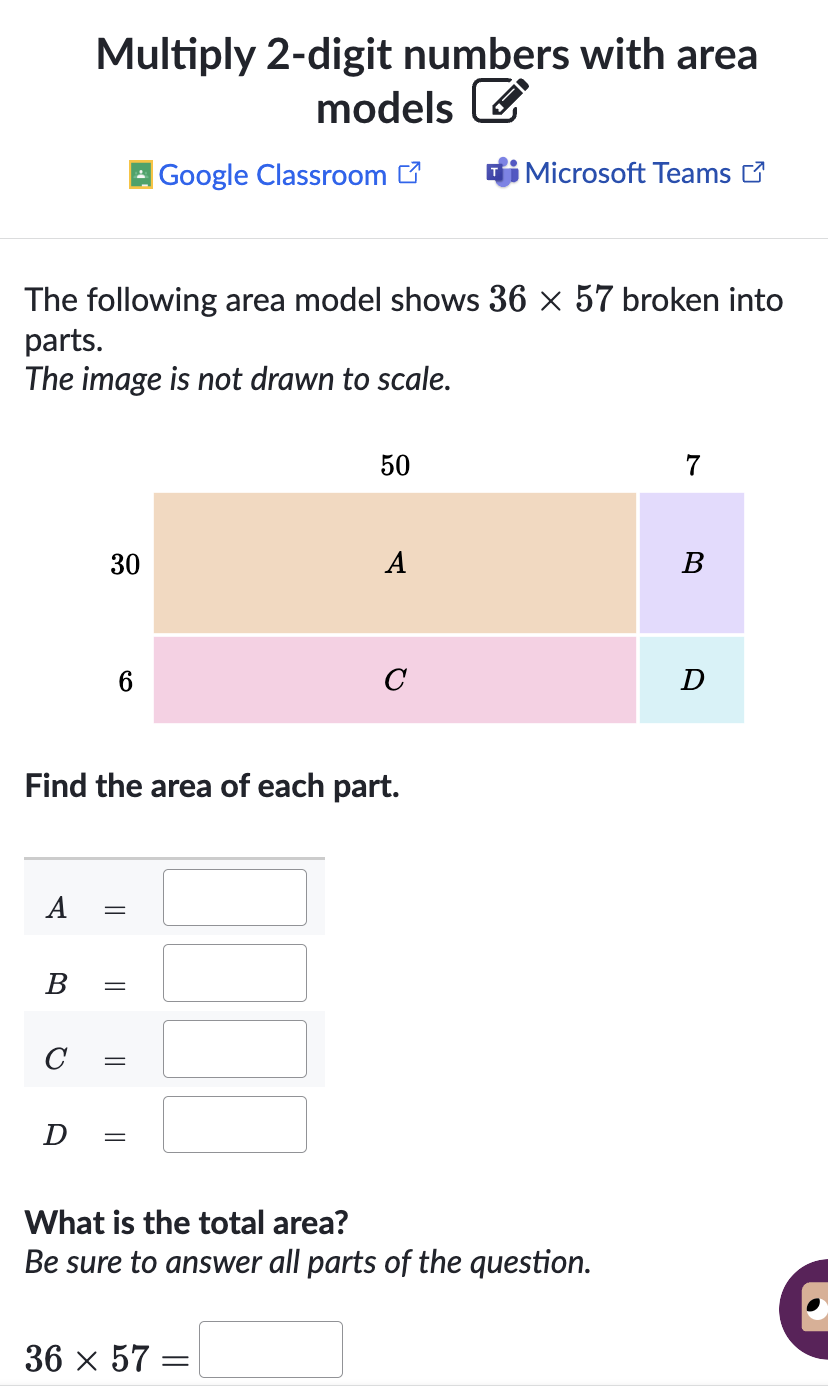
- multiply-using-partial-products: https://www.khanacademy.org/math/cc-fourth-grade-math/imp-multiplication-and-division-2/multiply-with-partial-products/e/multiply-using-partial-products
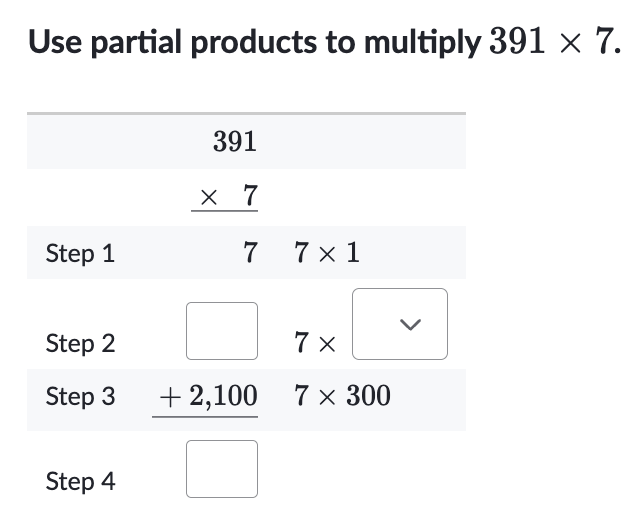
- multiply-with-partial-products--2-digit-numbers: https://www.khanacademy.org/math/cc-fourth-grade-math/multiplying-by-2-digit-numbers/multiply-2-digit-numbers-with-partial-products/e/multiply-with-partial-products--2-digit-numbers-
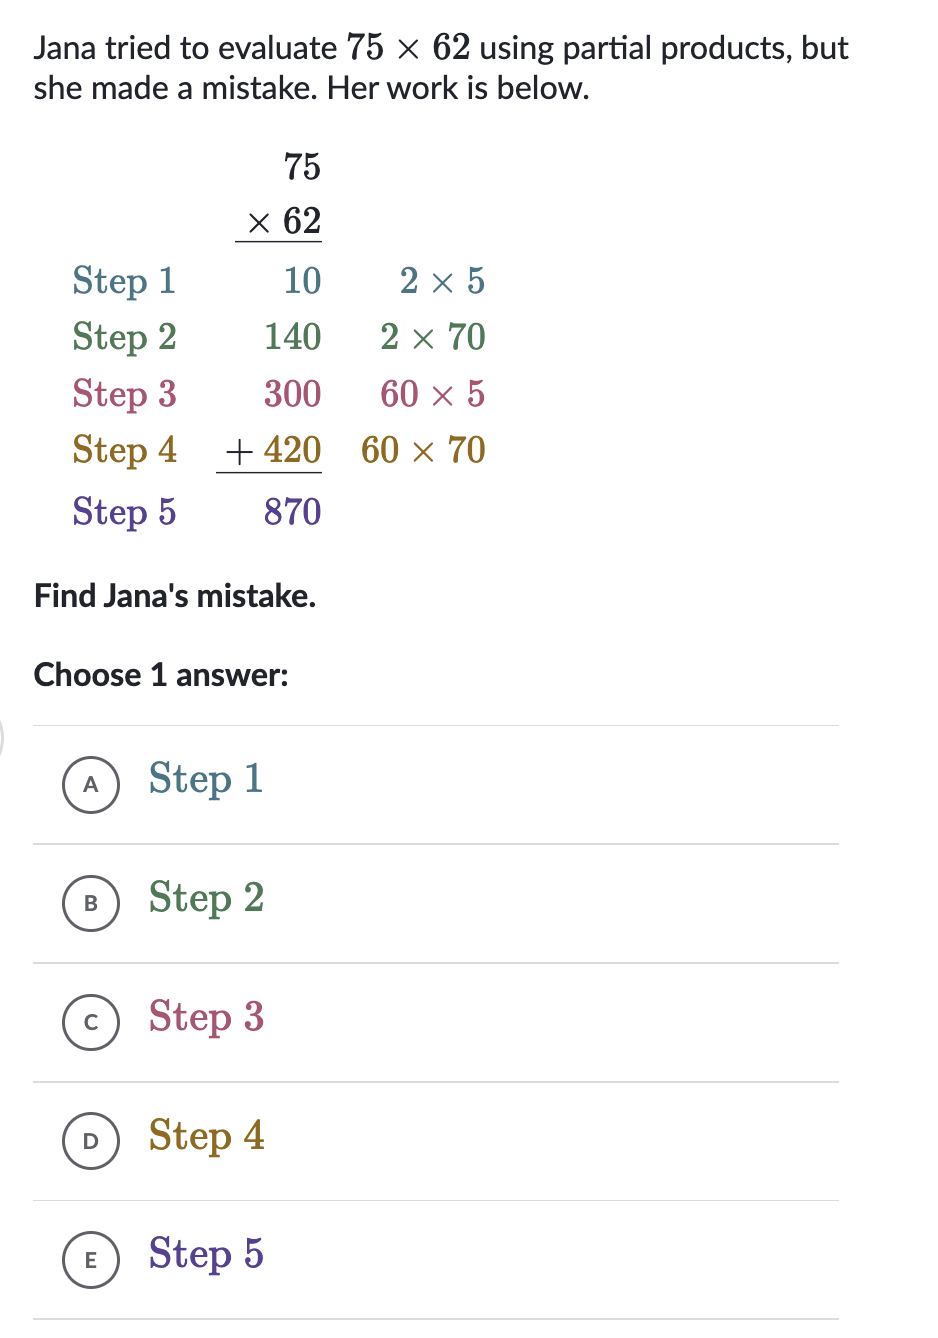

In [7]:
print("Current Skill: multiply-with-partial-products--2-digit-numbers")
print("\nPrerequisite Skills:")
for skill in conversation_manager.get_memory_context()[-1].split(";"):
    print(skill.strip())
print("\nConversation Results:")
result

Current Skill: multiply-with-partial-products--2-digit-numbers

Prerequisite Skills:
multiplying-2-digit-numbers-with-area-models: proficient
multiply-using-partial-products: familiar

Conversation Results:


,question,responses
0,I am having trouble using partial products to multiply 85 times 61,"Thanks for letting me know! Since you mentioned you’re having trouble with partial products, and your prerequisite skill ""multiply-using-partial-products"" is at the familiar level, it would be helpful to review that skill first. Practicing it will make multiplying 85 × 61 much easier!\n\n**Warm-up problem for ""multiply-using-partial-products"":**\n\nTry this: \nWhat are the partial products for \( 34 \times 12 \)? \n(Remember, break apart each number by place value and multiply each part!)\n\nLet me know your partial products, and I’ll help you check your work!"
1,"300, 40, 20, 8","Great job breaking it down into four partial products! Let's check each one together:\n\nFor \(34 \times 12\), you can break it down like this:\n- \(34 = 30 + 4\)\n- \(12 = 10 + 2\)\n\nNow, multiply each part:\n1. \(30 \times 10 = ?\)\n2. \(30 \times 2 = ?\)\n3. \(4 \times 10 = ?\)\n4. \(4 \times 2 = ?\)\n\nCan you match your answers (300, 40, 20, 8) to these four products? \nTry filling in the question marks above!"
2,1. 300 \n2. 60 \n3. 40 \n4. 8,"Awesome! You got it:\n\n1. \(30 \times 10 = 300\) \n2. \(30 \times 2 = 60\) \n3. \(4 \times 10 = 40\) \n4. \(4 \times 2 = 8\)\n\nNow, let's add up all the partial products: \n\(300 + 60 + 40 + 8 = ?\)\n\nWhat do you get as the final answer for \(34 \times 12\)?"
3,408.,"Perfect! \(34 \times 12 = 408\). You’ve got the hang of finding and adding partial products!\n\nNow, let’s use the same steps for your original problem: \n**What are the four partial products for \(85 \times 61\)?**\n\n(Remember to break apart 85 into 80 and 5, and 61 into 60 and 1. Then multiply each part!) \nWrite out each partial product, and I’ll help you check your work."
4,80 × 60 = 4800 \n80 × 1 = 80 \n5 × 60 = 300 \n5 × 1 = 5,"Excellent work! You broke down \(85 \times 61\) into all the correct partial products:\n\n- \(80 \times 60 = 4800\)\n- \(80 \times 1 = 80\)\n- \(5 \times 60 = 300\)\n- \(5 \times 1 = 5\)\n\nNow, add all the partial products together: \n\(4800 + 80 + 300 + 5 = ?\)\n\nWhat is the final answer for \(85 \times 61\)?"


In [ ]:
# Advanced Usage Examples and Testing

# Example 1: Different conversation lengths
print("=== Testing different conversation lengths ===")
print("Short conversation (2 turns):")
short_result = tutor(
    student_msg='I need help with 23 * 47', 
    kaid='kaid_248328473686127753888179', 
    skill_tag=' multiply-with-partial-products--2-digit-numbers-', 
    max_turns=2
)
display(short_result)

print("\nLonger conversation (5 turns):")
long_result = tutor(
    student_msg='I am confused about how to break down multiplication problems', 
    kaid='kaid_248328473686127753888179', 
    skill_tag=' multiply-with-partial-products--2-digit-numbers-', 
    max_turns=5
)
display(long_result)

# Example 2: Access conversation history and memory context
print("\n=== Accessing conversation internals ===")
print("Conversation history:")
for i, msg in enumerate(conversation_manager.get_conversation_history()[-4:]):  # Show last 4 messages
    print(f"{i+1}. {msg['role']}: {msg['content'][:100]}...")

print("\nMemory context (static per session):")
memory, skills, prereqs = conversation_manager.get_memory_context()
print(f"Skills: {skills[:200]}...")
print(f"Prerequisites: {prereqs[:200]}...")

# Example 3: Testing with different student personas or skill tags
print("\n=== Testing flexibility ===")
print("This system now supports:")
print("- Configurable conversation lengths (max_turns parameter)")
print("- Proper conversation history maintenance")
print("- Static memory retrieval (once per session)")
print("- Access to conversation internals for debugging/analysis")
print("- Backward compatibility with existing functions")
